# **1-Import of Main libraries**

In [13]:
import tensorflow as tf
from tensorflow.keras.layers import Dense,BatchNormalization,ReLU,Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.applications import EfficientNetB0,EfficientNetB3,EfficientNetB5,DenseNet121 , EfficientNetV2S
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.layers import TextVectorization
import pickle
import pandas as pd
from tensorflow.keras.layers import (
    Input, Embedding, LSTM, Dense, Dropout,
    LayerNormalization, Concatenate, Reshape, Attention,GlobalAveragePooling1D
)
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input,Reshape,LayerNormalization
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
IMG_SIZE = 224
Q_MAX_LEN = 32
A_MAX_LEN = 12
BATCH_SIZE=64

# **2-Preparing Pathes For Training and Preprocessing**

In [14]:
train_df = pd.read_csv("/kaggle/input/datasets/b0o0da/v4-qa-dataset/train_cleaned_v4.csv")
val_df   = pd.read_csv("/kaggle/input/datasets/b0o0da/v4-qa-dataset/val_cleaned_v4.csv")
test_df  = pd.read_csv("/kaggle/input/datasets/b0o0da/v4-qa-dataset/test_cleaned_v4.csv")



with open("/kaggle/input/datasets/b0o0da/v4-qa-dataset/question_vocab_V4.pkl", "rb") as f:
    Q_vocab = pickle.load(f)

Q_vectorizer = TextVectorization(
    max_tokens=len(Q_vocab),
    output_mode="int",
    output_sequence_length=Q_MAX_LEN
)

Q_vectorizer.set_vocabulary(Q_vocab)


with open("/kaggle/input/datasets/b0o0da/v4-qa-dataset/answer_vocab_V4.pkl", "rb") as f:
    A_vocab = pickle.load(f)

A_vectorizer = TextVectorization(
    max_tokens=len(A_vocab),
    output_mode="int",
    output_sequence_length=A_MAX_LEN
)

A_vectorizer.set_vocabulary(A_vocab)

In [15]:
import os
import pandas as pd

BASE_DIR = "/kaggle/input/datasets/b0o0da/visual-qa-dataset/dataset_images/dataset_images"

def fix_image_path(p):
    p = str(p).strip()
    filename = os.path.basename(p)
    return os.path.join(BASE_DIR, filename)

train_df["image_path"] = train_df["image_path"].apply(fix_image_path)
val_df["image_path"] = val_df["image_path"].apply(fix_image_path)
test_df["image_path"] = test_df["image_path"].apply(fix_image_path)


In [16]:
def preprocess_image(path):
    img = tf.io.read_file(path)
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.keras.applications.efficientnet.preprocess_input(img)
    return img

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [17]:
def make_dataset(df, Q_vectorizer, A_vectorizer, batch_size=BATCH_SIZE, shuffle=True):
    image_paths = df["image_path"].values
    questions   = df["question"].values
    answers     = df["answer"].values

    ds = tf.data.Dataset.from_tensor_slices((image_paths, questions, answers))

    if shuffle:
        ds = ds.shuffle(200, reshuffle_each_iteration=True)

    def process(path, question, answer):
        img   = preprocess_image(path)
        q_seq = Q_vectorizer(question)
        q_seq = q_seq[:-1]
        a_seq          = A_vectorizer(answer)
        decoder_input  = a_seq[:-1]
        target         = a_seq[1:]

        sample_weight  = tf.cast(target != 0, tf.float32)

        return (img, q_seq, decoder_input), target, sample_weight

    ds = ds.map(process, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = make_dataset(train_df, Q_vectorizer, A_vectorizer, batch_size=BATCH_SIZE, shuffle=True)
val_ds   = make_dataset(val_df,   Q_vectorizer, A_vectorizer, batch_size=BATCH_SIZE, shuffle=False)
test_ds  = make_dataset(test_df,  Q_vectorizer, A_vectorizer, batch_size=BATCH_SIZE, shuffle=False)

# **3-Build EfficientNetB5 ENCODER**

In [18]:
base_cnn = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    pooling=None
)

base_cnn.trainable = False

image_input = Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image_input")

x_img = data_augmentation(image_input)
x_img = base_cnn(x_img)

x_img = Reshape((-1, x_img.shape[-1]))(x_img)

x_img = Dense(256, activation="relu")(x_img)
x_img = LayerNormalization()(x_img)
x_img = Dropout(0.2)(x_img)

cnn_model = Model(inputs=image_input, outputs=x_img, name="cnn_branch")
cnn_model.summary()

Model: "cnn_branch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 49, 1280)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 49, 256)        │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_7           │ (None, 49, 256)        │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 49, 256)        │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,378,019 (16.70 MB)

 Trainable params: 328,448 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

# **4-Build RNN LSTM Decoder**

In [19]:
from tensorflow.keras.layers import (
    Input, Embedding, LSTM, Dense, Dropout,
    LayerNormalization, Concatenate, Reshape,
    MultiHeadAttention, Add
)

Q_VOCAB_SIZE = len(Q_vectorizer.get_vocabulary())
A_VOCAB_SIZE = len(A_vectorizer.get_vocabulary())

# =========================
# INPUTS
# =========================
image_input    = Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image_input")
question_input = Input(shape=(Q_MAX_LEN - 1,),        name="question_input")
answer_input   = Input(shape=(A_MAX_LEN - 1,),        name="answer_input")

# =========================
# IMAGE ENCODER
# =========================
img_feat = cnn_model(image_input)
img_feat = Reshape((-1, img_feat.shape[-1]))(img_feat)
img_feat = Dense(256, activation="relu")(img_feat)
img_feat = LayerNormalization()(img_feat)
img_feat = Dropout(0.2)(img_feat)                      # (None, 49, 256)

# =========================
# QUESTION ENCODER
# =========================
q = Embedding(Q_VOCAB_SIZE, 256, mask_zero=False)(question_input)
q = Dropout(0.2)(q)
q = LSTM(256, return_sequences=True)(q)                # (None, Q_MAX_LEN-1, 256)
q = LayerNormalization()(q)

# =========================
# ANSWER DECODER
# =========================
a = Embedding(A_VOCAB_SIZE, 256, mask_zero=False)(answer_input)
a = Dropout(0.2)(a)
a = LSTM(256, return_sequences=True)(a)                # (None, A_MAX_LEN-1, 256)
a = LayerNormalization()(a)

# =========================
# CROSS-ATTENTION على الصورة
# =========================
img_attn = MultiHeadAttention(num_heads=4, key_dim=64, dropout=0.1)(
    query=a, value=img_feat, key=img_feat
)
img_attn = LayerNormalization()(Add()([img_attn, a]))  # residual connection

# =========================
# CROSS-ATTENTION على السؤال
# =========================
q_attn = MultiHeadAttention(num_heads=4, key_dim=64, dropout=0.1)(
    query=img_attn, value=q, key=q
)
q_attn = LayerNormalization()(Add()([q_attn, img_attn]))  # residual connection

# =========================
# FUSION
# =========================
x = Dense(512, activation="relu")(q_attn)
x = Dropout(0.3)(x)
x = LayerNormalization()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.2)(x)

# =========================
# OUTPUT
# =========================
output = Dense(A_VOCAB_SIZE, activation="softmax")(x)  # (None, A_MAX_LEN-1, A_VOCAB_SIZE)

# =========================
# MODEL
# =========================
vqa_model = Model(
    inputs=[image_input, question_input, answer_input],
    outputs=output,
    name="vqa_cross_attention"
)
vqa_model.summary()

Model: "vqa_cross_attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_branch          │ (None, 49, 256)   │  4,378,019 │ image_input[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ answer_input        │ (None, 11)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 49, 256)   │          0 │ cnn_branch[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 11, 256)   │    768,000 │ answer_input[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 49, 256)   │     65,792 │ reshape_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 11, 256)   │          0 │ embedding_3[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ question_input      │ (None, 31)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 49, 256)   │        512 │ dense_6[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 11, 256)   │    525,312 │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 31, 256)   │     55,552 │ question_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 49, 256)   │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 11, 256)   │        512 │ lstm_3[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 31, 256)   │          0 │ embedding_2[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 11, 256)   │    263,168 │ dropout_9[0][0],  │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
│                     │                   │            │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 31, 256)   │    525,312 │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 11, 256)   │          0 │ multi_head_atten… │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 256)   │        512 │ lstm_2[0][0]      │
│ (LayerNormalizatio… │                   │            │                 

 Total params: 7,881,819 (30.07 MB)

 Trainable params: 3,832,248 (14.62 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

# **5-Build Custom Accuracy-Loss-BLEU Functions**

In [20]:
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=False,
    reduction="none"
)

def masked_loss(y_true, y_pred):
    # compute per-token loss
    loss = loss_object(y_true, y_pred)

    # mask padding tokens (0 = PAD)
    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)

    loss = loss * mask

    return tf.reduce_sum(loss) / tf.reduce_sum(mask)

def masked_accuracy(y_true, y_pred):
    # predicted word id
    y_pred_ids = tf.argmax(y_pred, axis=-1)

    # ensure same dtype
    y_true = tf.cast(y_true, tf.int32)
    y_pred_ids = tf.cast(y_pred_ids, tf.int32)

    # check matches
    matches = tf.cast(tf.equal(y_true, y_pred_ids), tf.float32)

    # mask padding
    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)

    matches = matches * mask

    return tf.reduce_sum(matches) / tf.reduce_sum(mask)

smooth = SmoothingFunction().method1

def ids_to_words(ids, vocab):
    words = []
    for idx in ids:
        idx = int(idx)
        if idx == 0:
            continue
        if idx >= len(vocab):
            continue
        word = vocab[idx]
        if word == "end":
            break
        if word != "start":
            words.append(word)
    return words

class BleuCallback(tf.keras.callbacks.Callback):
    def __init__(self, val_dataset, A_vocab, num_batches=5):
        super().__init__()
        self.val_dataset = val_dataset
        self.vocab = A_vocab
        self.num_batches = num_batches

    def on_epoch_end(self, epoch, logs=None):
        bleu_scores = []

        for batch in self.val_dataset.take(self.num_batches):
            if isinstance(batch, (tuple, list)):
                if len(batch) == 2:
                    inputs, y_true = batch
                elif len(batch) == 3:
                    inputs, y_true, _ = batch
                else:
                    continue
            else:
                continue

            y_pred = self.model.predict(inputs, verbose=0)
            y_pred_ids = np.argmax(y_pred, axis=-1)
            y_true = y_true.numpy()

            for true_seq, pred_seq in zip(y_true, y_pred_ids):
                ref = ids_to_words(true_seq, self.vocab)
                hyp = ids_to_words(pred_seq, self.vocab)

                if ref and hyp:
                    bleu_scores.append(
                        sentence_bleu([ref], hyp, smoothing_function=smooth)
                    )

        mean_bleu = np.mean(bleu_scores) if bleu_scores else 0.0
        logs = logs or {}
        logs["val_BLEU"] = mean_bleu
        print(f"\nval_BLEU: {mean_bleu:.4f}")

# **6-Compiling And Callbacks**

In [21]:
vqa_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=5e-4,
        clipnorm=1.0 
    ),
    loss=masked_loss,
    metrics=[masked_accuracy]
)

In [22]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    mode="min",
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_vqa_model.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

callbacks_list = [early_stop, reduce_lr, checkpoint]

# **7-Training Model**

In [23]:
train_imgs = set(train_df["image_path"].values)
val_imgs   = set(val_df["image_path"].values)
overlap    = train_imgs & val_imgs

print(f"Overlap in images: {len(overlap)}")

train_q = set(train_df["question"].values)
val_q   = set(val_df["question"].values)

train_a = set(train_df["answer"].values)
val_a = set(val_df["answer"].values)

print(f"Overlap in questions: {len(train_q & val_q)}")
print(f"Overlap in answer: {len(train_a & val_a)}")

Overlap in images: 0
Overlap in questions: 71
Overlap in answer: 911


In [24]:
vocab = A_vectorizer.get_vocabulary()

bleu_callback = BleuCallback(val_ds, vocab)

history = vqa_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks_list + [bleu_callback],
    verbose=1
)

Epoch 1/10


E0000 00:00:1778647407.624328     186 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/vqa_cross_attention_1/cnn_branch_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


1083/1083 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - loss: 2.3915 - masked_accuracy: 0.1702
Epoch 1: val_loss improved from inf to 2.98099, saving model to best_vqa_model.keras

val_BLEU: 0.0119
1083/1083 ━━━━━━━━━━━━━━━━━━━━ 256s 217ms/step - loss: 2.3916 - masked_accuracy: 0.1702 - val_loss: 2.9810 - val_masked_accuracy: 0.1218 - learning_rate: 5.0000e-04 - val_BLEU: 0.0119
Epoch 2/10
1083/1083 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - loss: 1.6793 - masked_accuracy: 0.2777
Epoch 2: val_loss did not improve from 2.98099

val_BLEU: 0.0185
1083/1083 ━━━━━━━━━━━━━━━━━━━━ 220s 203ms/step - loss: 1.6795 - masked_accuracy: 0.2777 - val_loss: 3.1265 - val_masked_accuracy: 0.1657 - learning_rate: 5.0000e-04 - val_BLEU: 0.0185
Epoch 3/10
1083/1083 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - loss: 1.4349 - masked_accuracy: 0.3288
Epoch 3: val_loss improved from 2.98099 to 2.94482, saving model to best_vqa_model.keras

val_BLEU: 0.0223
1083/1083 ━━━━━━━━━━━━━━━━━━━━ 221s 204ms/step - loss: 1.4351 - masked_accura

# **8-Fine Tuning Step**

In [25]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    mode="min",
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_vqa_model_ft.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)


callbacks_list = [early_stop, reduce_lr, checkpoint]

base_cnn.trainable = True

for layer in base_cnn.layers[:-60]:
    layer.trainable = False

vqa_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=masked_loss,
    metrics=[masked_accuracy]
)

history_ft = vqa_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=callbacks_list + [bleu_callback],
    verbose=1
)

Epoch 1/8


E0000 00:00:1778649652.038998     186 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/vqa_cross_attention_1/cnn_branch_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


1083/1083 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - loss: 1.3864 - masked_accuracy: 0.3739
Epoch 1: val_loss improved from inf to 2.39285, saving model to best_vqa_model_ft.keras

val_BLEU: 0.0395
1083/1083 ━━━━━━━━━━━━━━━━━━━━ 308s 259ms/step - loss: 1.3865 - masked_accuracy: 0.3739 - val_loss: 2.3928 - val_masked_accuracy: 0.3229 - learning_rate: 1.0000e-05 - val_BLEU: 0.0395
Epoch 2/8
1083/1083 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - loss: 1.2046 - masked_accuracy: 0.4070
Epoch 2: val_loss improved from 2.39285 to 2.34995, saving model to best_vqa_model_ft.keras

val_BLEU: 0.0412
1083/1083 ━━━━━━━━━━━━━━━━━━━━ 275s 254ms/step - loss: 1.2048 - masked_accuracy: 0.4070 - val_loss: 2.3499 - val_masked_accuracy: 0.3313 - learning_rate: 1.0000e-05 - val_BLEU: 0.0412
Epoch 3/8
1083/1083 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - loss: 1.1253 - masked_accuracy: 0.4273
Epoch 3: val_loss improved from 2.34995 to 2.34078, saving model to best_vqa_model_ft.keras

val_BLEU: 0.0427
1083/1083 ━━━━━━━━━━━━━━━━━━

In [26]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    mode="min",
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_vqa_model_ft_2.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

callbacks_list = [early_stop, reduce_lr, checkpoint]

base_cnn.trainable = True

for layer in base_cnn.layers[:-80]:
    layer.trainable = False

vqa_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=5e-4,
        clipnorm=1.0 
    ),
    loss=masked_loss,
    metrics=[masked_accuracy]
)

history_ft_2 = vqa_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=6,
    callbacks=callbacks_list + [bleu_callback],
    verbose=1
)

Epoch 1/6


E0000 00:00:1778652004.414281     186 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/vqa_cross_attention_1/cnn_branch_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


1083/1083 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - loss: 0.9212 - masked_accuracy: 0.4874
Epoch 1: val_loss improved from inf to 3.24570, saving model to best_vqa_model_ft_2.keras

val_BLEU: 0.0296
1083/1083 ━━━━━━━━━━━━━━━━━━━━ 312s 261ms/step - loss: 0.9214 - masked_accuracy: 0.4874 - val_loss: 3.2457 - val_masked_accuracy: 0.2446 - learning_rate: 5.0000e-04 - val_BLEU: 0.0296
Epoch 2/6
1083/1083 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - loss: 0.8436 - masked_accuracy: 0.5121
Epoch 2: val_loss did not improve from 3.24570

val_BLEU: 0.0286
1083/1083 ━━━━━━━━━━━━━━━━━━━━ 275s 253ms/step - loss: 0.8437 - masked_accuracy: 0.5121 - val_loss: 3.5174 - val_masked_accuracy: 0.2451 - learning_rate: 5.0000e-04 - val_BLEU: 0.0286
Epoch 3/6
1083/1083 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - loss: 0.7844 - masked_accuracy: 0.5389
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 3: val_loss did not improve from 3.24570

val_BLEU: 0.0307
1083/1083 ━━━━━━━━━━━━━━━━━━━━ 274s 253

# **9-Quick Evaluation for Model**

In [28]:
vqa_model = tf.keras.models.load_model(
    r"/kaggle/working/best_vqa_model_ft.keras",
    custom_objects={"masked_loss": masked_loss,
                    "masked_accuracy": masked_accuracy}
)

results = vqa_model.evaluate(test_ds, verbose=1)

print("\nValidation Loss     :", results[0])
print("Validation Accuracy :", results[1])

137/137 ━━━━━━━━━━━━━━━━━━━━ 35s 215ms/step - loss: 1.9665 - masked_accuracy: 0.3724

Validation Loss     : 2.396479606628418
Validation Accuracy : 0.336801141500473


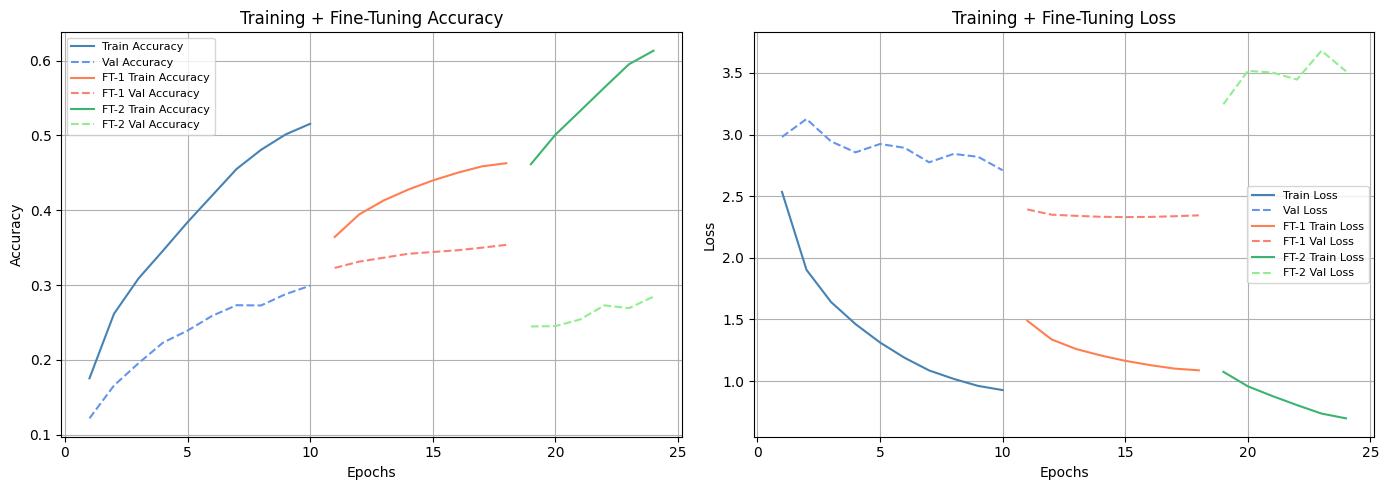

In [30]:
train_acc      = history.history['masked_accuracy']
val_acc        = history.history['val_masked_accuracy']
ft_train_acc   = history_ft.history['masked_accuracy']
ft_val_acc     = history_ft.history['val_masked_accuracy']
ft_train_acc_2 = history_ft_2.history['masked_accuracy']
ft_val_acc_2   = history_ft_2.history['val_masked_accuracy']

train_loss      = history.history['loss']
val_loss        = history.history['val_loss']
ft_train_loss   = history_ft.history['loss']
ft_val_loss     = history_ft.history['val_loss']
ft_train_loss_2 = history_ft_2.history['loss']
ft_val_loss_2   = history_ft_2.history['val_loss']

# ====== Epochs ======
n1 = len(train_acc)
n2 = len(ft_train_acc)
n3 = len(ft_train_acc_2)

epochs_base = range(1,        n1 + 1)
epochs_ft1  = range(n1 + 1,   n1 + n2 + 1)
epochs_ft2  = range(n1 + n2 + 1, n1 + n2 + n3 + 1)

plt.figure(figsize=(14, 5))

# ====== Accuracy ======
plt.subplot(1, 2, 1)
plt.plot(epochs_base, train_acc,      label='Train Accuracy',          color='steelblue')
plt.plot(epochs_base, val_acc,        label='Val Accuracy',            color='cornflowerblue', linestyle='--')
plt.plot(epochs_ft1,  ft_train_acc,   label='FT-1 Train Accuracy',     color='coral')
plt.plot(epochs_ft1,  ft_val_acc,     label='FT-1 Val Accuracy',       color='salmon',        linestyle='--')
plt.plot(epochs_ft2,  ft_train_acc_2, label='FT-2 Train Accuracy',     color='mediumseagreen')
plt.plot(epochs_ft2,  ft_val_acc_2,   label='FT-2 Val Accuracy',       color='lightgreen',    linestyle='--')
plt.title('Training + Fine-Tuning Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(fontsize=8)
plt.grid(True)

# ====== Loss ======
plt.subplot(1, 2, 2)
plt.plot(epochs_base, train_loss,      label='Train Loss',          color='steelblue')
plt.plot(epochs_base, val_loss,        label='Val Loss',            color='cornflowerblue', linestyle='--')
plt.plot(epochs_ft1,  ft_train_loss,   label='FT-1 Train Loss',     color='coral')
plt.plot(epochs_ft1,  ft_val_loss,     label='FT-1 Val Loss',       color='salmon',        linestyle='--')
plt.plot(epochs_ft2,  ft_train_loss_2, label='FT-2 Train Loss',     color='mediumseagreen')
plt.plot(epochs_ft2,  ft_val_loss_2,   label='FT-2 Val Loss',       color='lightgreen',    linestyle='--')
plt.title('Training + Fine-Tuning Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(fontsize=8)
plt.grid(True)

plt.tight_layout()
plt.show()